In [ ]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal,Annotated
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_core.messages import SystemMessage, HumanMessage
import operator
import os

In [35]:
load_dotenv()
_default_model = os.environ["GROQ_MODEL"]
generative_model = ChatGroq(model=os.getenv("GROQ_GENERATION_MODEL", _default_model))
evaluation_model = ChatGroq(model=os.getenv("GROQ_EVALUATION_MODEL", _default_model))
optimization_model = ChatGroq(model=os.getenv("GROQ_EVALUATION_MODEL", _default_model))

In [36]:
from pydantic import BaseModel,Field
class TweetEvaluation(BaseModel):
    evaluation: Literal['Approved','Needs Improvement'] = Field(description="Evaluation result for the generated tweet")
    feedback: str = Field(description="Feedback for the tweet if evaluation is 'Needs Improvement'")

In [37]:
structured_evaluator_llm=evaluation_model.with_structured_output(TweetEvaluation)

In [38]:
class TweetPost(TypedDict):
    topic: str
    tweet: str
    evaluation: Literal['Approved','Needs Improvement']
    feedback: str
    iteration: int
    max_iterations: int
    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]


In [39]:
def generate_tweet(state:TweetPost)->TweetPost:
    messages=[
        SystemMessage(content="You are a funny and clever tweeter/X infulencer  tasked with creating engaging tweets on various topics. Your goal is to craft a tweet that captures attention and encourages interaction."),
        HumanMessage(content=f"""Write a tweet on the topic: {state['topic']}. The tweet should be short original, engaging, and relevant to the topic.
                     Rules:
                     do not use question answer format.
                     max 200 charecters.
                     use obeservational humor,irony,surcasm or cultural refereces.
                     think in meme logic,punchlines or relatable takes.
                     use simple day to day english. """ )
    ]
    response=generative_model.invoke(messages).content
    return {'tweet':response,'tweet_history':[response]}



In [40]:
def evaluate_tweet(state:TweetPost)->TweetPost:
    messages=[
        SystemMessage(content="You are a discerning and insightful social media critic tasked with evaluating the quality of tweets. Your goal is to assess the tweet's creativity, relevance, and potential for engagement based on the provided topic."),
        HumanMessage(content=f"""Evaluate the following tweet based on the topic: {state['topic']} and the tweet: {state['tweet']}.
                     Criteria:
                     Creativity: Does the tweet demonstrate originality and cleverness in its approach to the topic?
                     Relevance: Is the tweet closely related to the given topic and does it effectively address it?
                     Engagement Potential: Does the tweet have elements that could encourage likes, retweets, or comments?
                     Provide an overall evaluation of 'Approved' if the tweet meets these criteria or 'Needs Improvement' if it falls short. Additionally, offer specific feedback on what aspects of the tweet could be enhanced to increase its appeal and effectiveness.
                     ### response only in structured format:
                     evaluation:approved or needs_improvement
                     feedback:one paragraph explaining the strenght and weaknesses""" )
    ]
    response=structured_evaluator_llm.invoke(messages)
    return {'evaluation':response.evaluation,'feedback':response.feedback,'feedback_history':[response.feedback]}

In [41]:
def optimize_tweet(state:TweetPost)->TweetPost:
    messages=[
        SystemMessage(content="You are a skilled and creative social media strategist tasked with optimizing tweets for maximum engagement. Your goal is to enhance the tweet's appeal, relevance, and potential for interaction based on the provided topic and feedback."),
        HumanMessage(content=f"""Optimize the following tweet based on the topic: {state['topic']}, the original tweet: {state['tweet']}, and the feedback: {state['feedback']}.
                     Consider the following aspects when optimizing:
                     Re-write it as a short,viral worthy tweet. avoid Q&A style and stay under 250 characters""" )
    ]
    response=optimization_model.invoke(messages).content
    iteration=state['iteration']+1
    return {'tweet':response,'iteration':iteration,'tweet_history':[response]}

In [42]:
def route_evaluation(state:TweetPost)->str:
    if state['evaluation']=='Approved' or state['iteration']>=state['max_iterations']:
        return 'Approved'
    else:
        return 'Needs improvement'

In [43]:
graph=StateGraph(TweetPost)
graph.add_node('generate',generate_tweet)
graph.add_node('evaluate',evaluate_tweet)
graph.add_node('optimize',optimize_tweet)
graph.add_edge(START,'generate')
graph.add_edge('generate','evaluate')
graph.add_conditional_edges('evaluate',route_evaluation,{'Approved':END,'Needs Improvement':'optimize'})
graph.add_edge('optimize','evaluate')
workflow=graph.compile()


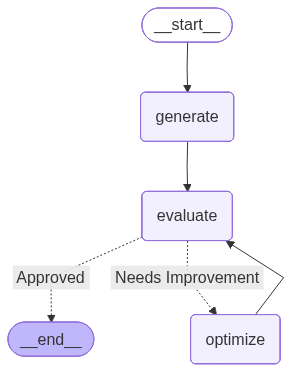

In [17]:
workflow

In [44]:
initial_state={
    'topic':'indian Railways',
    'iteration':1,
    'max_iterations':4
}
workflow.invoke(initial_state)

{'topic': 'indian Railways',
 'tweet': '"Indian Railways: where a 10-hour journey is a 20-hour adventure, but at least the chai is always on time #RailwayLife #IndianRail"',
 'evaluation': 'Approved',
 'feedback': 'The tweet demonstrates creativity by using a humorous and relatable tone to express the frustrations and joys of traveling with Indian Railways. It is closely related to the topic and effectively addresses it by highlighting the unpredictable nature of the journey and the one constant that passengers can rely on - the timely serving of chai. The use of hashtags #RailwayLife and #IndianRail also enhances its engagement potential by making it discoverable to a wider audience. However, to further increase its appeal, the tweet could benefit from more vivid language or a surprising statistic to make it more memorable and shareable.',
 'iteration': 1,
 'max_iterations': 4,
 'tweet_history': ['"Indian Railways: where a 10-hour journey is a 20-hour adventure, but at least the chai 